[-0.71514865  0.53091379  0.80562397 ... -2.76010409  1.61160296
 -0.27391227]


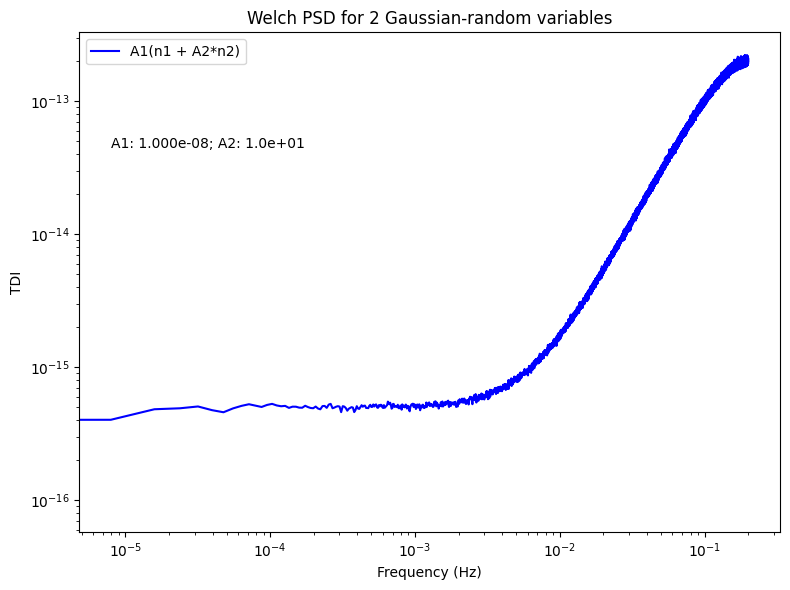

In [32]:
from scipy.signal import welch
import numpy as np
from lisaconstants import ASTRONOMICAL_YEAR
import matplotlib.pyplot as plt

rng = np.random.default_rng()

dt = 2.5
numTotTimes = int(2 * ASTRONOMICAL_YEAR / dt)

# Total time series
noise1 = rng.normal(loc = 0.0, scale = 1.0, size = numTotTimes)
noise2 = np.diff(rng.normal(loc = 0.0, scale = 1.0, size = numTotTimes), prepend = 0)
A1 = 10**(-8)  # 10**(-15)
A2 = 10
noiseTot = A1 * (noise1 + noise2 * A2)

nSegs = 500
noiseTotSpectrum = welch(noiseTot, fs = 1/dt, nperseg = numTotTimes / nSegs)

plt.figure(figsize = (8, 6))
plt.plot(noiseTotSpectrum[0], noiseTotSpectrum[1], color = 'blue', label = 'A1(n1 + A2*n2)')
plt.text(noiseTotSpectrum[0][1], np.max(noiseTotSpectrum[1]) * 0.2, f'A1: {A1:.3e}; A2: {A2:.1e}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('TDI')
plt.legend()
plt.loglog()
plt.title('Welch PSD for 2 Gaussian-random variables')
plt.tight_layout()
plt.savefig('Gaussian random noise.jpg')

print(noise2)

In [47]:
with h5py.File('imageData5/h5_out/train_img_0000.h5') as f:
    print(f['params']['tC'][0])
    print(np.array(f['indiv_waveforms']['wf_0']))

28903630.539031472
[ 9.10594121e-24  9.59432396e-24  1.22223168e-23 ... -2.28838788e-19
 -2.33245789e-19 -2.37451674e-19]


In [42]:
with h5py.File('imageData5/train_ready.h5') as f:
    dt_dec = float(f.attrs['dt_dec'])          # = 40.0
    grp = f['test_img_0000']
    n_bhb = len(grp['tC'])
    for k in range(n_bhb):
        vs_idx = grp['visible_start'][k]        # decimated sample index
        tC = grp['tC'][k]                       # seconds
        if vs_idx < 0:
            print(f"BHB {k}: never visible (trash)")
            continue
        vs_sec = vs_idx * dt_dec                # -> seconds
        vis_duration_sec = tC - vs_sec          # how long it's visible before merger
        print(f"BHB {k}: visible for {vis_duration_sec:.3e} s "
              f"= {vis_duration_sec/86400:.2f} days   "
              f"(vs_idx={vs_idx}, tC={tC:.3e}s)")
        print(f"  params: {grp['params'][k]}")
        print(grp['params'].shape[0], len(grp['tC']), len(grp['visible_start']))

BHB 0: visible for 7.181e+05 s = 8.31 days   (vs_idx=1089397, tC=4.429e+07s)
  params: [0.2519263  0.91498876]
11 11 11
BHB 1: visible for 1.178e+06 s = 13.64 days   (vs_idx=402367, tC=1.727e+07s)
  params: [0.15032862 0.93681496]
11 11 11
BHB 2: visible for 2.919e+06 s = 33.79 days   (vs_idx=826842, tC=3.599e+07s)
  params: [0.4730687  0.36599824]
11 11 11
BHB 3: visible for 2.640e+06 s = 30.55 days   (vs_idx=411813, tC=1.911e+07s)
  params: [0.9457786 0.9244202]
11 11 11
BHB 4: visible for 2.029e+06 s = 23.48 days   (vs_idx=453040, tC=2.015e+07s)
  params: [0.97622687 0.7551277 ]
11 11 11
BHB 5: visible for 3.059e+06 s = 35.40 days   (vs_idx=0, tC=3.059e+06s)
  params: [0.82583827 0.18928736]
11 11 11
BHB 6: visible for 2.077e+06 s = 24.04 days   (vs_idx=418087, tC=1.880e+07s)
  params: [0.814773  0.4547758]
11 11 11
BHB 7: visible for 2.037e+06 s = 23.57 days   (vs_idx=335869, tC=1.547e+07s)
  params: [0.4156659  0.49484205]
11 11 11
BHB 8: visible for 1.597e+06 s = 18.49 days   (vs